In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("healthcare_disease_dataset .csv")

In [95]:
print(df.head())

   Age  Gender Blood Pressure Cholesterol Glucose Smoking Alcohol Consumption  \
0   69    Male           High        High    High     Yes                  No   
1   32    Male            Low        High  Normal     Yes                  No   
2   89  Female         Normal        High  Normal      No                  No   
3   78    Male           High        High    High      No                  No   
4   38    Male            Low      Normal  Normal     Yes                 Yes   

  Exercise    BMI Family History  Heart Disease  Diabetes  Stroke  \
0       No  35.67             No              1         0       0   
1      Yes  38.55            Yes              0         1       0   
2      Yes  18.93            Yes              1         0       0   
3      Yes  21.81            Yes              0         1       1   
4      Yes  37.55             No              0         0       0   

   Kidney Disease  Cancer  Alzheimer's Disease  COPD  Liver Disease  \
0               0       1  

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   in

In [8]:
df.describe().all()

Age                     True
BMI                     True
Heart Disease          False
Diabetes               False
Stroke                 False
Kidney Disease         False
Cancer                 False
Alzheimer's Disease    False
COPD                   False
Liver Disease          False
Parkinson's Disease    False
Tuberculosis           False
dtype: bool

In [11]:
df.isnull().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

In [12]:
df.isnull().sum().sum()

0

In [13]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking',
       'Alcohol Consumption', 'Exercise', 'BMI', 'Family History',
       'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
       'Alzheimer's Disease', 'COPD', 'Liver Disease', 'Parkinson's Disease',
       'Tuberculosis'],
      dtype='object')

In [99]:
# Standardize column names
df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [100]:
df.columns

Index(['age', 'gender', 'blood_pressure', 'cholesterol', 'glucose', 'smoking',
       'alcohol_consumption', 'exercise', 'bmi', 'family_history',
       'heart_disease', 'diabetes', 'stroke', 'kidney_disease', 'cancer',
       'alzheimer's_disease', 'copd', 'liver_disease', 'parkinson's_disease',
       'tuberculosis'],
      dtype='object')

In [101]:
# check duplicate exist if true, means duplicate exist, else not (false) 
df.duplicated().any()

False

In [102]:
# shows duplicate values
df[df.duplicated()]

,age,gender,blood_pressure,cholesterol,glucose,smoking,alcohol_consumption,exercise,bmi,family_history,heart_disease,diabetes,stroke,kidney_disease,cancer,alzheimer's_disease,copd,liver_disease,parkinson's_disease,tuberculosis


In [16]:
# Remove duplicates
df = df.drop_duplicates()

In [103]:
# Convert categorical values
df['gender'] = df['gender'].astype('category')

In [23]:
df.columns

Index(['age', 'gender', 'blood_pressure', 'cholesterol', 'glucose', 'smoking',
       'alcohol_consumption', 'exercise', 'bmi', 'family_history',
       'heart_disease', 'diabetes', 'stroke', 'kidney_disease', 'cancer',
       'alzheimer's_disease', 'copd', 'liver_disease', 'parkinson's_disease',
       'tuberculosis'],
      dtype='object')

In [96]:
df.head(20)

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.67,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.55,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.93,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.81,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.55,No,0,0,0,0,0,0,0,0,0,0
5,41,Male,High,High,High,Yes,No,No,28.36,Yes,1,0,0,0,0,1,0,0,0,0
6,20,Male,Normal,Normal,High,No,No,Yes,30.64,Yes,0,0,0,1,0,0,0,0,0,0
7,39,Female,Low,Normal,Normal,No,No,Yes,32.76,No,0,1,0,1,0,0,0,0,0,0
8,70,Male,Normal,High,Normal,No,No,Yes,33.10,No,0,0,0,0,0,1,0,0,0,0
9,19,Male,Normal,High,High,No,No,Yes,38.53,Yes,1,1,0,0,0,0,0,0,0,0


EDA

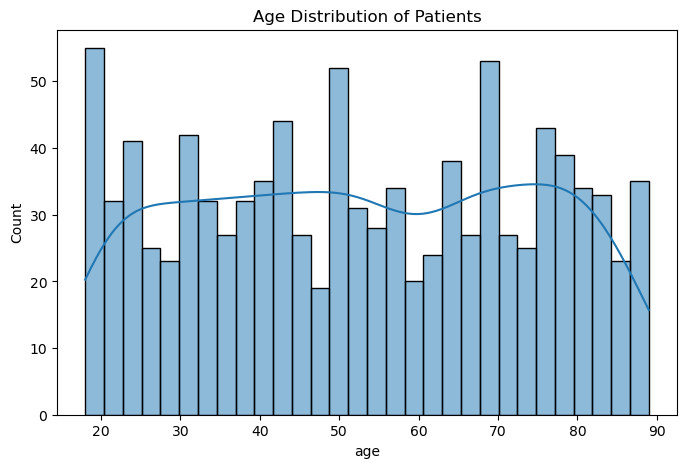

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

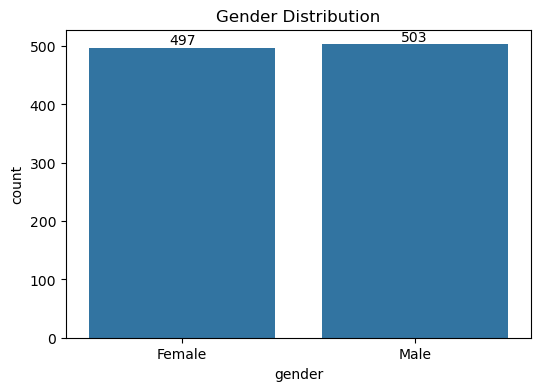

In [35]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
ax.bar_label(ax.containers[0])
plt.show()

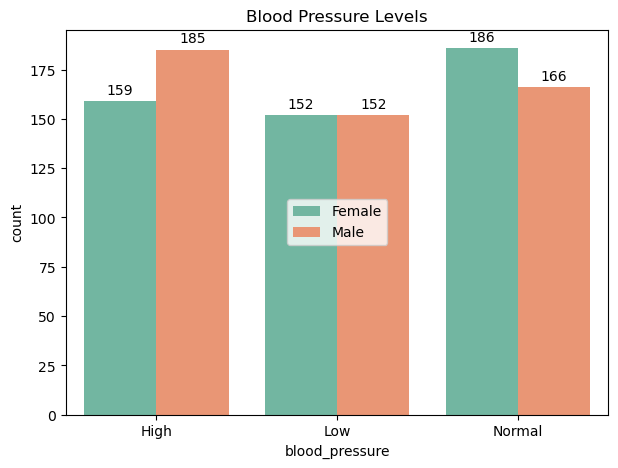

In [51]:
plt.figure(figsize=(7,5))
ax=sns.countplot(x='blood_pressure', data=df, palette="Set2",hue="gender")
plt.title("Blood Pressure Levels")
plt.legend(loc='center')

for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

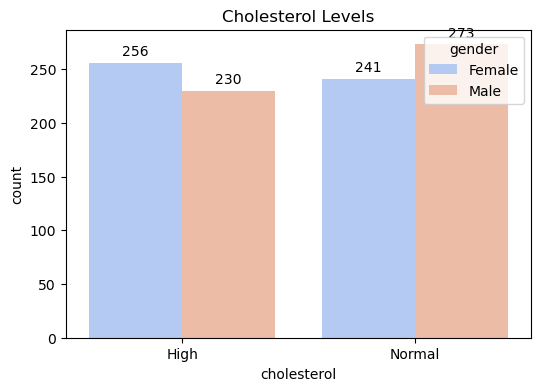

In [55]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x='cholesterol', data=df,hue='gender', palette="coolwarm")
plt.title("Cholesterol Levels")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_13940\958237868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='smoking', y='heart_disease', data=df,palette="coolwarm")


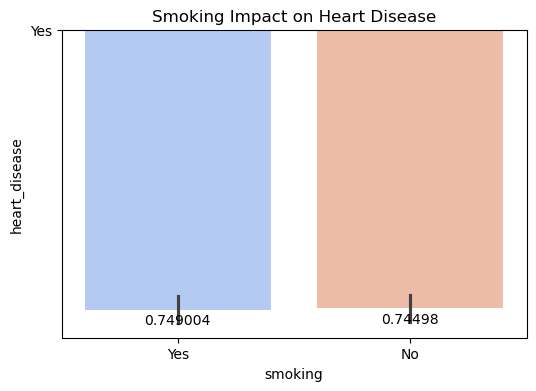

In [59]:
plt.figure(figsize=(6,4))
ax=sns.barplot(x='smoking', y='heart_disease', data=df,palette="coolwarm")
plt.title("Smoking Impact on Heart Disease")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

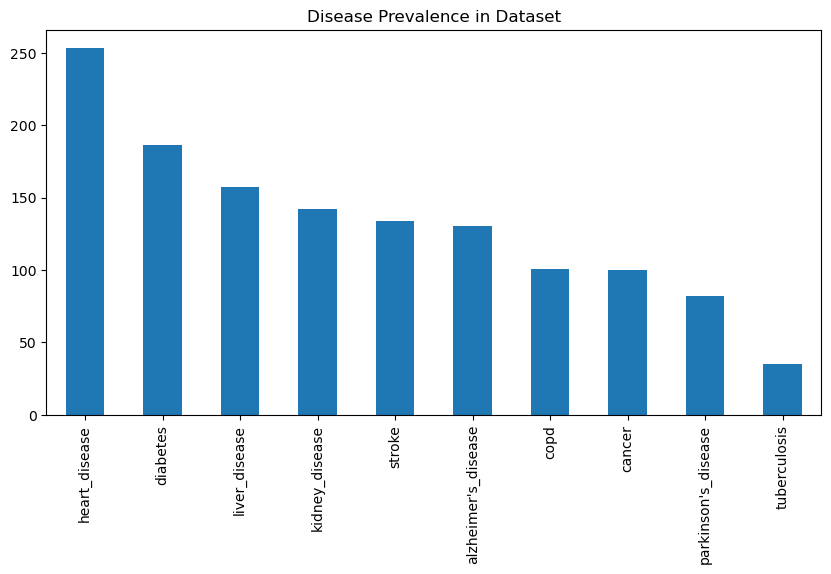

In [104]:
diseases = [
    'heart_disease','diabetes','stroke','kidney_disease',
    'cancer',"alzheimer's_disease",'copd','liver_disease',
    "parkinson's_disease",'tuberculosis'
]

df[diseases].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Disease Prevalence in Dataset")
plt.show()

In [105]:
# coonecting to mysql

In [108]:
import pandas as pd
from sqlalchemy import create_engine

# Assuming your cleaned data is in a DataFrame called 'df'
# For example, if you read and cleaned data earlier:
# df = pd.read_csv("cleaned_customer_data.csv")

# MySQL credentials
username = 'root'
password = '1234'
host = 'localhost'        # or your MySQL server IP
port = 3306
database = 'health'

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write the cleaned DataFrame to MySQL table
table_name = 'health_tble'  # Name of the table in MySQL
df.to_sql(name='health_tble', con=engine, if_exists='replace', index=False)

# Read first 5 rows from MySQL to verify
result = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5;", con=engine)
print(result)

   age  gender blood_pressure cholesterol glucose smoking alcohol_consumption  \
0   69    Male           High        High    High     Yes                  No   
1   32    Male            Low        High  Normal     Yes                  No   
2   89  Female         Normal        High  Normal      No                  No   
3   78    Male           High        High    High      No                  No   
4   38    Male            Low      Normal  Normal     Yes                 Yes   

  exercise    bmi family_history  heart_disease  diabetes  stroke  \
0       No  35.67             No              1         0       0   
1      Yes  38.55            Yes              0         1       0   
2      Yes  18.93            Yes              1         0       0   
3      Yes  21.81            Yes              0         1       1   
4      Yes  37.55             No              0         0       0   

   kidney_disease  cancer  alzheimer's_disease  copd  liver_disease  \
0               0       1  